In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [22]:

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "nikhil7280/student-performance-multiple-linear-regression"
)

print("Dataset downloaded to:")
print(path)

print("\nFiles in the dataset:")
print(os.listdir(path))

csv_file = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break
    if csv_file:
        break

print("\nCSV File Found:")
print(csv_file)

df = pd.read_csv(csv_file)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.
Dataset downloaded to:
/kaggle/input/student-performance-multiple-linear-regression

Files in the dataset:
['Student_Performance.csv']

CSV File Found:
/kaggle/input/student-performance-multiple-linear-regression/Student_Performance.csv

First 5 Rows:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2            

In [25]:
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [23]:

X = df[["Hours Studied", "Previous Scores", "Sleep Hours"]].values

y = df["Performance Index"].values

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (10000, 3)
Target Shape: (10000,)


In [9]:
print(df.shape)

df.info()

df.describe()

(10000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [10]:
X = df[["Hours Studied", "Previous Scores", "Sleep Hours"]].values

y = df["Performance Index"].values

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [13]:
m, n = X_train.shape

weights = np.zeros(n)

bias = 0

learning_rate = 0.01

epochs = 1000

In [14]:
def predict(X, w, b):
    return np.dot(X, w) + b

In [15]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [16]:
loss_history = []

for epoch in range(epochs):

    y_pred = predict(X_train, weights, bias)

    dw = (-2/m) * np.dot(X_train.T, (y_train - y_pred))

    db = (-2/m) * np.sum(y_train - y_pred)

    weights -= learning_rate * dw

    bias -= learning_rate * db

    loss = mse(y_train, y_pred)

    loss_history.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} Loss = {loss:.4f}")

Epoch 0 Loss = 3428.0350
Epoch 100 Loss = 64.9764
Epoch 200 Loss = 5.6294
Epoch 300 Loss = 4.5819
Epoch 400 Loss = 4.5634
Epoch 500 Loss = 4.5631
Epoch 600 Loss = 4.5631
Epoch 700 Loss = 4.5631
Epoch 800 Loss = 4.5631
Epoch 900 Loss = 4.5631


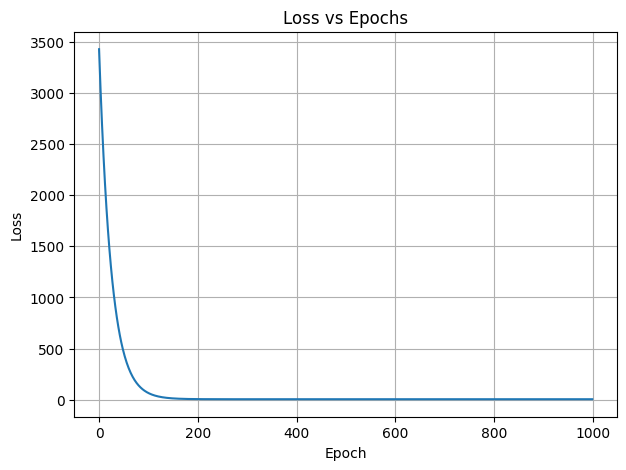

In [27]:
plt.figure(figsize=(7,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epochs")

plt.grid(True)
plt.savefig(
    "results/loss_vs_epochs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
y_pred = predict(X_test, weights, bias)

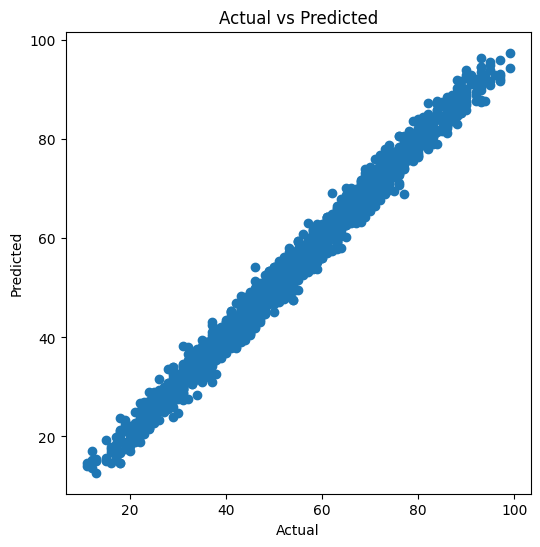

In [26]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")
plt.savefig(
    "results/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [20]:
mae = mean_absolute_error(y_test, y_pred)

mse_value = mean_squared_error(y_test, y_pred)

print("MAE =", mae)

print("MSE =", mse_value)

MAE = 1.7044084295697712
MSE = 4.545107887691117


In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

sk_pred = model.predict(X_test)

print("Scikit-learn Coefficients:")

print(model.coef_)

print("Scikit-learn Intercept:")

print(model.intercept_)

print("MAE =", mean_absolute_error(y_test, sk_pred))

print("MSE =", mean_squared_error(y_test, sk_pred))

Scikit-learn Coefficients:
[ 7.41025008 17.6440538   0.80400163]
Scikit-learn Intercept:
55.31150000000001
MAE = 1.7044084321401278
MSE = 4.545107899420578
